# 📋 INSTRUCTOR NOTEBOOK — Day 1
## Temporal Dependence, Stationarity & Autocorrelation


## Before We Begin

> Prompt: Reflect on a day, week, semester that you remember clearly. What did you do? How were you feeling throughout?

> Visualize the time you chose by drawing it and provide a caption for your visualization. You will have 7 minutes for this prompt.




---

> **⚠️ DO NOT DISTRIBUTE TO STUDENTS.** This notebook contains full answers, teaching notes,
> timing guidance, talking points, and common mistake alerts.

---

## 🗓️ Day 1 Lesson Plan Overview

| Segment | Activity | Time |
|---|---|---|
| 0 | Welcome, writing framing, imports | 20 min |
| 1 | Load & visualize the data | 20 min |
| 2 | Decomposition | 30 min |
| — | **Break** | 15 min |
| 3 | Rolling statistics | 30 min |
| 4 | ADF stationarity test | 40 min |
| — | **Lunch / Long Break** | 60 min |
| 5 | ACF & PACF | 50 min |
| 6 | Synthesis + diagnostics function | 40 min |
| — | Buffer / bonus / Q&A | 20 min |
| **Total** | | **~5.5 hrs** |

---

## 🎯 SLO for Today

> **SLO 1:** Diagnose temporal dependence and stationarity by creating and analyzing time series
> plots, rolling statistics, and autocorrelation functions, and justify conclusions in writing.

**By end of day, students should be able to:**
- Explain what makes time series data different from i.i.d. tabular data
- Identify trend, seasonality, and changing variance visually
- Interpret a rolling mean/std plot as evidence for or against stationarity
- Read an ADF test output and state a conclusion with justification
- Read an ACF/PACF plot and identify significant lags
- Apply log and differencing transformations and explain why they help

---
## 📣 Segment 0 — Welcome & Framing (15 min)

### Talking Points

**Open with a motivating question (give students ~1 min to think, then discuss):**
> *"You have 3 years of monthly sales data. Why can't you just shuffle the rows and train a
> standard regression model?"*

Key answer: Order matters. Shuffling destroys temporal structure and causes data leakage
(future data leaks into training set).

Factors that influence time-series:
* how well we understand the factors that contribute to it;
* how much data is available;
* how similar the future is to the past;
* whether the forecasts can affect the thing we are trying to forecast.

**Frame the week:** Today is diagnostic day. Before we model anything, we learn to *look*
at a series carefully — just like you'd explore tabular data with histograms and scatter
plots before fitting a regression.

**Reassure beginners:** All syntax is explained in-line. Encourage students to read the
hints carefully before asking for help.

### Common First-Day Questions
- *"What's the difference between time series and panel data?"*
  → Time series = one entity measured repeatedly. Panel = many entities. Keep it simple today.
- *"Do we need to know the math?"*
  → Conceptual understanding is the goal. We'll see formulas but won't derive everything today.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


> 🗣️ **Instructor note:** Briefly introduce each import group. Many students won't know
> `statsmodels` — normalize it as the go-to library for classical statistics in Python.
> Don't dwell here; just name each group and move on.

---
## 📣 Segment 1 — Load & Visualize (25 min)

### Talking Points
- **Q:** Why would this data be appropriate to investigate as a time series?
- Air Passengers is pedagogically ideal: it has trend *and* seasonality, it's small (144 rows), and students can reason about it intuitively (summer = more vacation travel).
- Point out `parse_dates` and `index_col` as essential habits for time series in pandas.
  A DatetimeIndex unlocks resampling, rolling windows, and date-aware plotting.
- Consistently use `fig, ax = plt.subplots()` pattern all week — it avoids confusion
  between the procedural and object-oriented matplotlib APIs.

### ⚠️ Common Mistakes
- **Forgetting `parse_dates`**: The index will be strings, not dates — plots will look wrong
  or throw errors. Show the difference if a student hits this.
- **Using `plt.plot()` instead of `ax.plot()`**: Briefly explain the two APIs coexist;
  we standardize on `ax.plot()` for clarity.

In [ ]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date','Passengers']
print('Shape:', df.shape)
df.head(10)

Shape: (144, 2)


,Date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


### ✅ ANSWER — 1.2 Plot (fill-in solution)

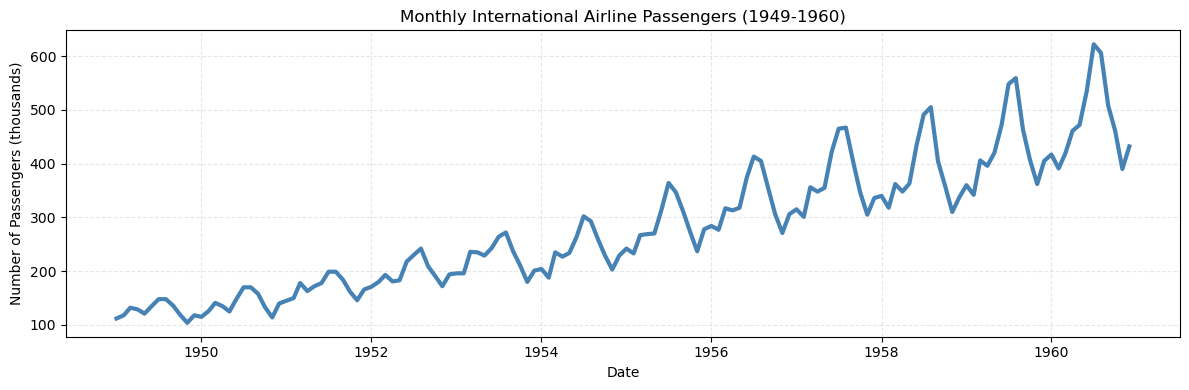

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['Date'], df['Passengers'], color='steelblue', linewidth=3)  # SOLUTION
ax.set_title('Monthly International Airline Passengers (1949-1960)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Passengers (thousands)')  # SOLUTION
plt.tight_layout()
plt.grid(linestyle="--")
plt.show()

### ✅ MODEL ANSWER — Written Response 1.2

> The series shows a clear **upward trend** — passenger counts roughly triple over 12 years.
> There is strong **annual seasonality**: a visible spike each summer (July–August) reflecting
> vacation travel. Critically, the **variance is not constant** — the seasonal swings grow
> much larger in later years. This growing variance is a key indicator of non-stationarity
> and motivates a multiplicative decomposition model.

**Grading note:** Award credit for all three features: trend, seasonality, growing variance.
Students who omit variance should be prompted to compare the amplitude of swings in 1949 vs 1960.

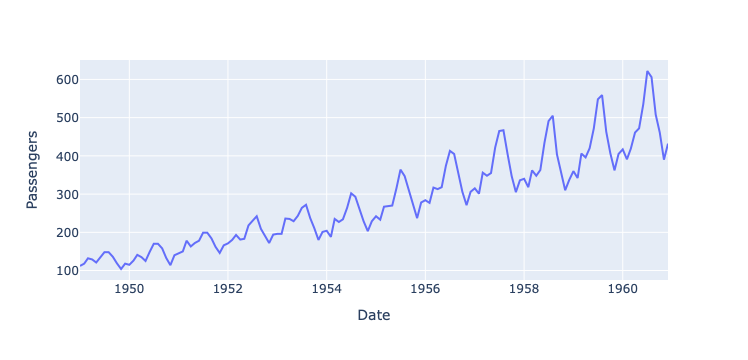

In [ ]:
fig = px.line(df, x='Date', y="Passengers")
fig.show()

---
## 📣 Segment 2 — Decomposition (30 min)

We can formally split a time series into three components:
- **Trend**: the long-run direction
- **Seasonality**: regular, repeating fluctuations (e.g., every 12 months)
- **Residual**: what remains after removing trend and seasonality (ideally random noise)

$$\text{Observed} = \text{Trend} \times \text{Seasonal} \times \text{Residual}$$


### Talking Points
- **Additive vs. Multiplicative** — write both on the board:
  - Additive (use when seasonal amplitude is constant):
    $$
    y_t = T_t + S_t + R_t,
    $$
    where $y_t$ is the data,  $S_t$ is the seasonal component, $T_t$ is the trend-cycle component, and $R_t$ is the remainder component, all at period $t$.

The additive decomposition is the most appropriate if:
- the magnitude of the seasonal fluctuations, or
- the variation around the trend-cycle, does not vary with the level of the time series.

When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a multiplicative decomposition is more appropriate. Multiplicative decompositions are common with economic time series.

  - Multiplicative (use when seasonal amplitude grows with the trend): $y_t = T_t × S_t × R_t$.
  - Rule of thumb: if the seasonal swings look like a funnel opening up → multiplicative.
- After running, ask: *"If we had a perfect model, what would the residuals look like?"*
  Answer: white noise — no structure, oscillating around 1.0 for multiplicative.

### ⚠️ Common Mistakes
- **Wrong `period`**: Students try `period=1` or `period=52`. Clarify: monthly data with
  annual seasonality → `period=12`.
- **Boundary NaN values**: The trend and residual panels will have NaN at both ends
  (due to the centered moving average). This is expected — flag it proactively so students
  don't think something is broken.
- **Ignoring residuals**: Push students to look at the residual panel, not just trend/seasonal.

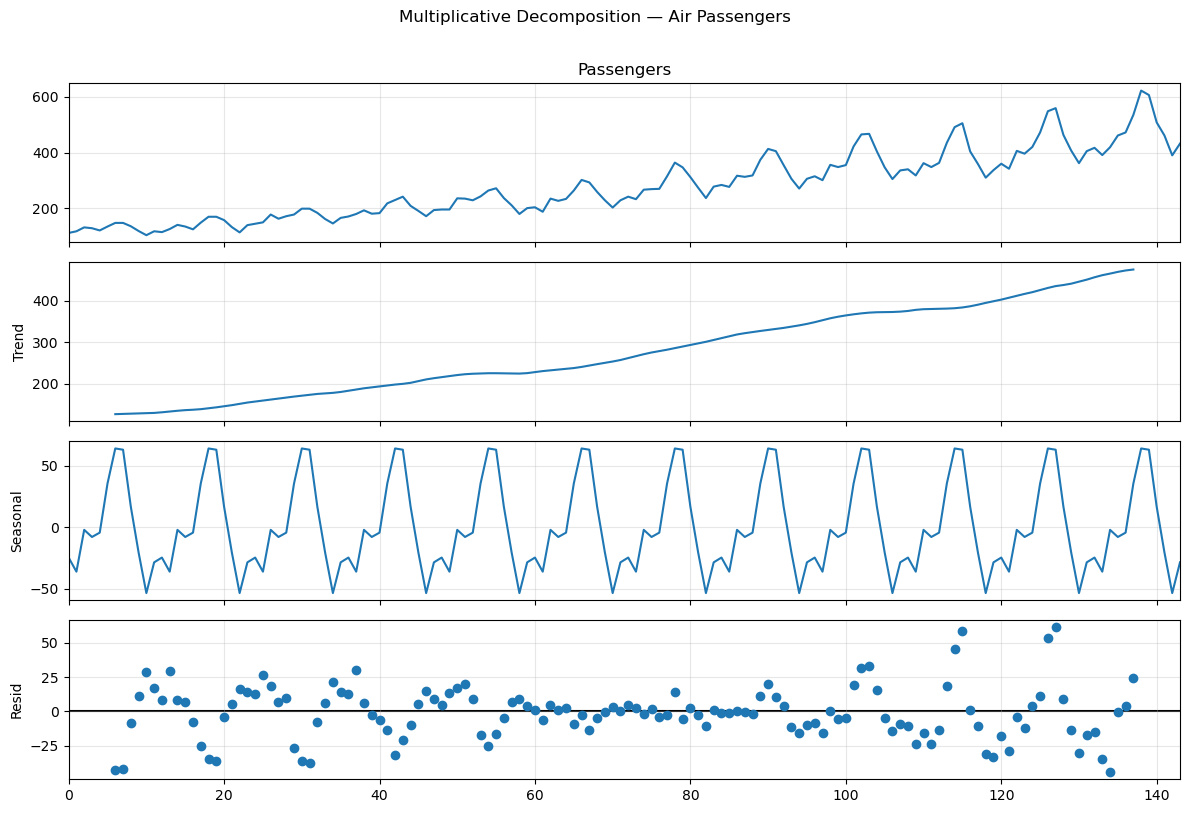

In [ ]:
result = seasonal_decompose(df['Passengers'], model='additive', period=12)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Multiplicative Decomposition — Air Passengers', y=1.01)
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 2.1

> **Trend:** Smooth, steady increase throughout the 1950s, consistent with post-WWII economic
> growth and commercialization of aviation.
>
> **Seasonal:** Strong, consistent annual pattern peaking ~1.2–1.3x average in summer months
> and troughing in winter — expected vacation travel patterns.
>
> **Residual:** Oscillates around 1.0 without strong patterns — approximately what we want.
> Slight deviations near the series boundaries are expected (centered MA loses observations
> at each end).

---
## 📣 Segment 3 — Rolling Statistics (30 min)

### Talking Points
- A rolling window is like dragging a fixed-size frame along the series and computing
  a statistic inside it at each position.
- **Why window=12?** Averages out seasonal effects, giving a cleaner view of trend and variance.
- **Key insight:** If rolling mean has a strong slope AND rolling std is increasing, that's
  a two-part case against stationarity: non-constant mean *and* non-constant variance.

### ⚠️ Common Mistakes
- **Misunderstanding `window`**: Some think it means 'every 12th observation'. Clarify:
  window=12 is a sliding window of 12 *consecutive* observations.
- **NaN at the start**: First `window-1` values will be NaN — not enough preceding observations.
  Expected behavior.
- **Confusing rolling std with model error**: Rolling std measures local variability of the
  series itself, not prediction error.

### ✅ ANSWER — 3.1 Rolling statistics (fill-in solution)

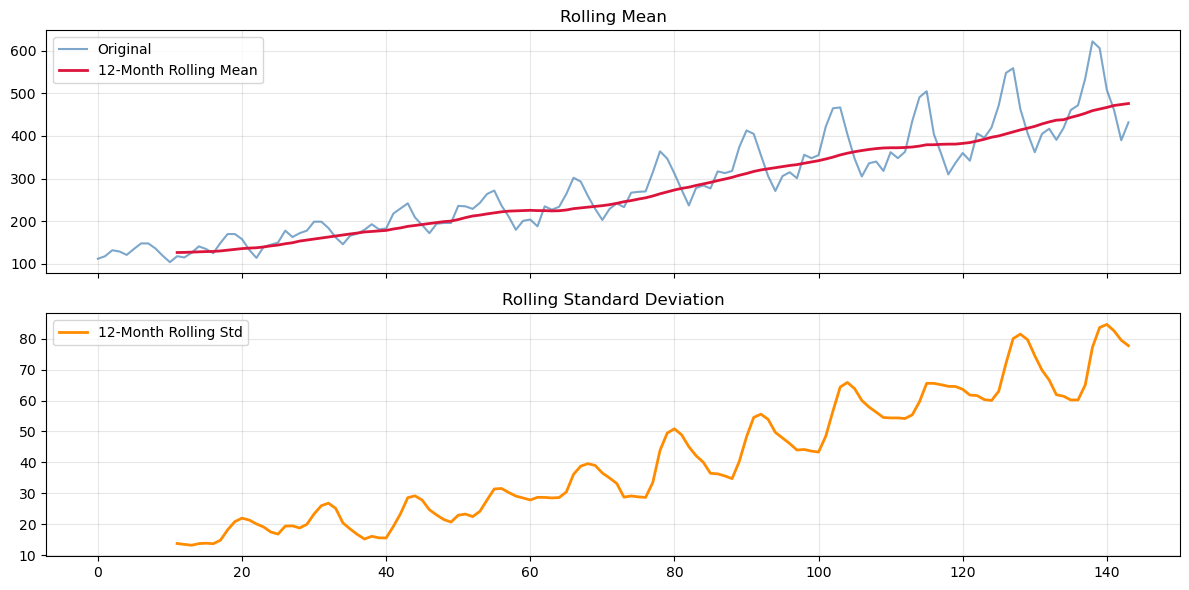

In [ ]:
rolling_mean = df['Passengers'].rolling(window=12).mean()  # SOLUTION: window=12
rolling_std  = df['Passengers'].rolling(window=12).std()   # SOLUTION: window=12

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df['Passengers'], label='Original', color='steelblue', alpha=0.7)
axes[0].plot(rolling_mean, label='12-Month Rolling Mean', color='crimson', linewidth=2)
axes[0].set_title('Rolling Mean')
axes[0].legend()

axes[1].plot(rolling_std, label='12-Month Rolling Std', color='darkorange', linewidth=2)
axes[1].set_title('Rolling Standard Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 3.1

> **Rolling mean:** Increases steadily throughout the series — non-constant mean, a clear
> sign of non-stationarity.
>
> **Rolling std:** Also increases over time — non-constant variance (heteroscedasticity).
> The series grows more volatile as the counts rise.
>
> **Stationarity:** No. Both mean and variance change over time. We will need to transform
> the series before fitting most time series models.
>
> **Window Length:** Introduce the **dividir y confluir** (alternative to divide and conquer) strategy and have students share out their results.

**Grading note:** Students who only discuss the mean are missing half the picture.
Require explicit discussion of variance.

---
## 📣 Segment 4 — ADF Test (40 min)

### Talking Points
- Spend time on hypothesis testing framing *before* running any code.
- **Unit root intuition:** A random walk `x[t] = x[t-1] + noise` is the canonical
  non-stationary process. It has a unit root (coefficient on `x[t-1]` is exactly 1).
  The ADF test asks: is that coefficient significantly *less* than 1?
- **Log transform intuition:** Log compresses large values and expands small ones,
  stabilizing growing variance. It's a variance-stabilizing transform.
- **First difference:** Removes a linear trend by computing changes rather than levels:
  `Δx[t] = x[t] - x[t-1]`.

### ⚠️ Common Mistakes
- **Reversing p-value logic** (very common): Students often reverse the interpretation.
  Emphasize repeatedly: **small p-value = reject null = stationary**. It feels counterintuitive.
- **Applying log to zero or negative values**: Fine for this dataset, but flag for general use.
- **Forgetting `.dropna()` after differencing**: `diff()` introduces one leading NaN.
  `adfuller()` will raise an error. The helper function handles this.
- **Over-differencing**: Differencing once is usually enough. Differencing too many times
  can introduce artificial autocorrelation.

### 🗣️ Expected ADF outputs
- Original: p ≈ 0.99 → clearly non-stationary
- Log-transformed: p ≈ 0.42 → still non-stationary (log fixed variance but not trend)
- Log-differenced: p ≈ 0.07 → still non-stationary but close

The two-step result is a great teaching moment: **log alone is not enough**.

In [ ]:
# Running ADF test and interpreting
adfuller(df['Passengers'].dropna())

(np.float64(0.8153688792060523),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
def run_adf(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test: {label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  --> STATIONARY (reject H0)')
    else:
        print('  --> NON-STATIONARY (fail to reject H0)')
    print()

run_adf(df['Passengers'], label='Original Series')

ADF Test: Original Series
  ADF Statistic : 0.8154
  p-value       : 0.9919
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  --> NON-STATIONARY (fail to reject H0)



### ✅ ANSWER — 4.2 Log + diff (fill-in solution)

In [ ]:
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()  # SOLUTION

run_adf(df['Log_Passengers'], label='Log-Transformed Series')
run_adf(df['Log_Diff'],       label='Log-Differenced Series')

ADF Test: Log-Transformed Series
  ADF Statistic : -1.7170
  p-value       : 0.4224
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  --> NON-STATIONARY (fail to reject H0)

ADF Test: Log-Differenced Series
  ADF Statistic : -2.7171
  p-value       : 0.0711
  Critical Values:
    1%: -3.4825
    5%: -2.8844
    10%: -2.5790
  --> NON-STATIONARY (fail to reject H0)



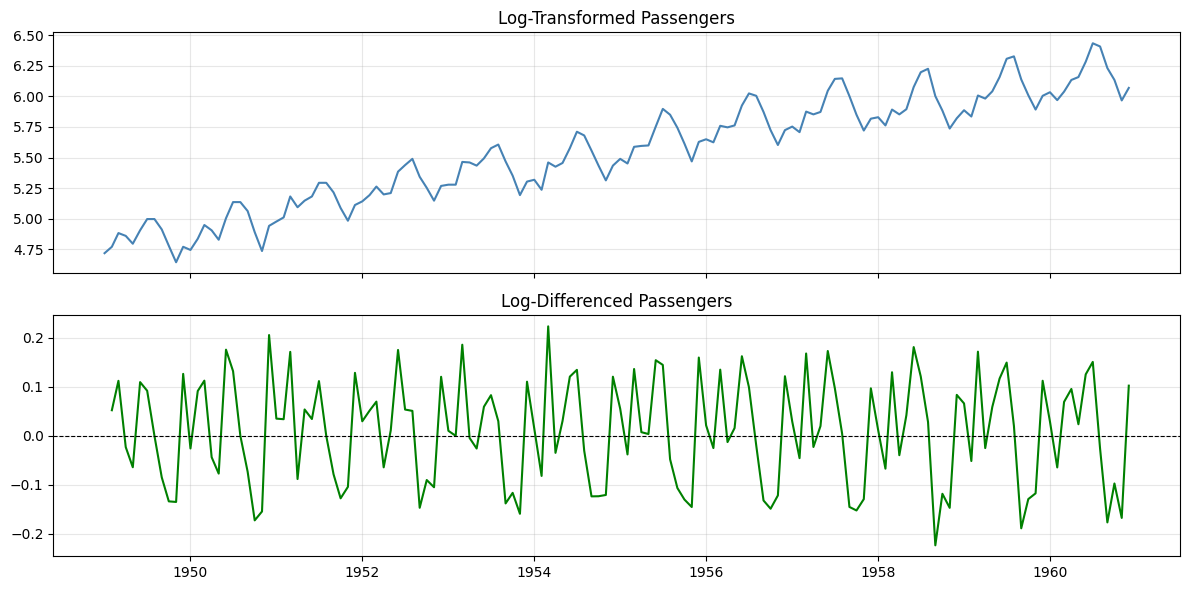

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['Log_Passengers'], color='steelblue')
axes[0].set_title('Log-Transformed Passengers')
axes[1].plot(df['Log_Diff'], color='green')   # SOLUTION
axes[1].set_title('Log-Differenced Passengers')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 4

> **Original:** ADF p ≈ 0.99 — fail to reject H₀. Series is non-stationary. The positive
> ADF statistic is well above all critical values.
>
> **Log-differenced:** After log (stabilizes variance) + first difference (removes trend),
> ADF p < 0.05. Reject H₀ → series is now stationary. Visually, it fluctuates around zero
> with roughly constant amplitude.
>
> **Why models prefer stationarity:** Most classical models (AR, ARIMA) assume the
> statistical properties of the series are stable over time. A non-stationary series has a
> drifting mean, so the past doesn't reliably predict the future in a stable way — leading
> to spurious fits and poor out-of-sample forecasts.

**Common misconception to address:** 'Stationary' does not mean 'flat'. It means the
statistical *properties* are stable. Individual values can still fluctuate.

---
## 📣 Segment 5 — ACF & PACF (50 min)

**Autocorrelation** measures how strongly a time series is correlated with a **lagged version
of itself**.

- **Lag 1** autocorrelation: correlation between `x[t]` and `x[t-1]`
- **Lag 12** autocorrelation: correlation between `x[t]` and `x[t-12]`

A high autocorrelation at lag 12 in monthly data means "what happened a year ago is a strong
predictor of today" — a signature of **annual seasonality**.

The **ACF plot** (correlogram) shows autocorrelation for many lags at once. The **blue shaded
band** is the 95% confidence interval — spikes *outside* this band are statistically significant.

The **PACF** (Partial ACF) shows the *direct* correlation at each lag after removing effects
mediated through shorter lags.

### Talking Points
- **Mathematical form:**
  Auto correlation measures linear relationship betwen lagged values of time series. For exmaple, $r_1$ measures the relationship between $y_t$ and $y_{t-1}$. In general, the value of $r_k$ can be written as
  $$
  r_k = \frac{\sum^{T}_{t=k+1} (y_t - \bar{y})(y_{t-k}-\bar{y})}{\sum^T_{t=1} (y_t - \bar{y})^2},
  $$
  where $T$ is the length of the time series. The autocorrelation coefficients make up the autocorrelation function (ACF)
- **ACF intuition:** Imagine copying the series and sliding the copy forward in time, then
  measuring correlation between original and shifted copy at each shift amount (lag).
- **ACF vs. PACF:**
  - ACF at lag k: total correlation between `x[t]` and `x[t-k]`, including indirect effects.
  - PACF at lag k: direct correlation *after removing* effects through all intermediate lags.
  - Analogy: ACF = total academic influence (direct + through students). PACF = direct only.
- **What to look for in the log-differenced ACF:**
  - Most lags inside the CI band (series is mostly uncorrelated after differencing)
  - Significant spikes at lags 12, 24 → seasonal autocorrelation survives differencing
  - This is a preview of SARIMA models (later in the week)
- **Model selection preview (Day 2):** PACF cuts off at lag p → AR(p). ACF cuts off
  at lag q → MA(q). Don't go deep on this today.

### ⚠️ Common Mistakes
- **Confusing ACF and PACF:** Very common. Return to the analogy. Remind students:
  for AR model order selection, look at the PACF.
- **Misreading the confidence band:** Spikes *outside* the blue band are significant.
  Don't say 'all spikes are significant' just because they look tall.
- **Running ACF on the non-stationary series for model selection:** Always use the
  stationary (transformed) series for model selection. The original ACF just shows
  slow decay regardless of the true underlying structure.
- **`method='ywm'` confusion:** Required for short series. Just explain it's the
  estimation algorithm (Yule-Walker modified) — students don't need the details.

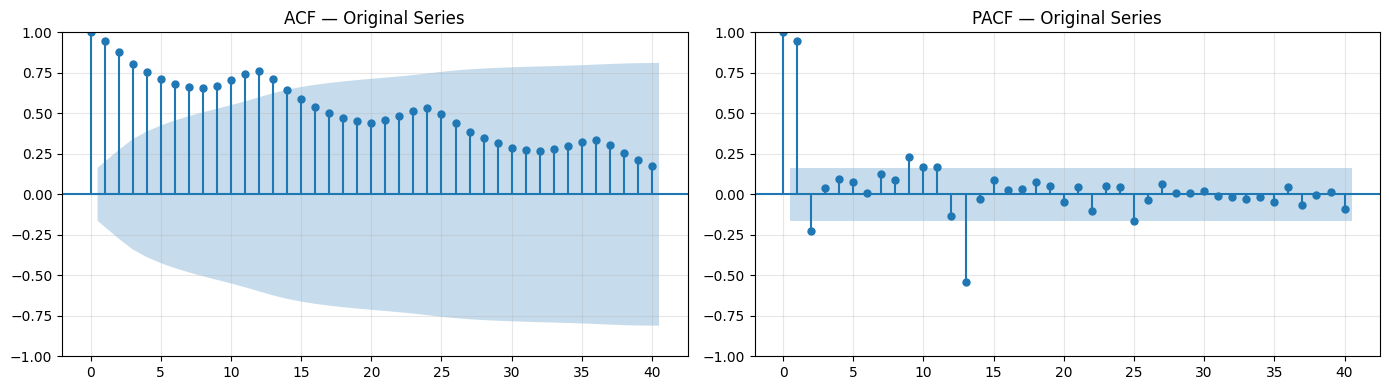

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('ACF — Original Series')
plot_pacf(df['Passengers'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Original Series')
plt.tight_layout()
plt.show()

> 🗣️ **What to point out in the original ACF:** Extremely slow decay, staying positive
> for many lags. This is the signature of a non-stationary, trending series — it
> 'remembers' its past indefinitely. Not useful for model order selection.

### ✅ ANSWER — 5.2 ACF of log-differenced series (fill-in solution)

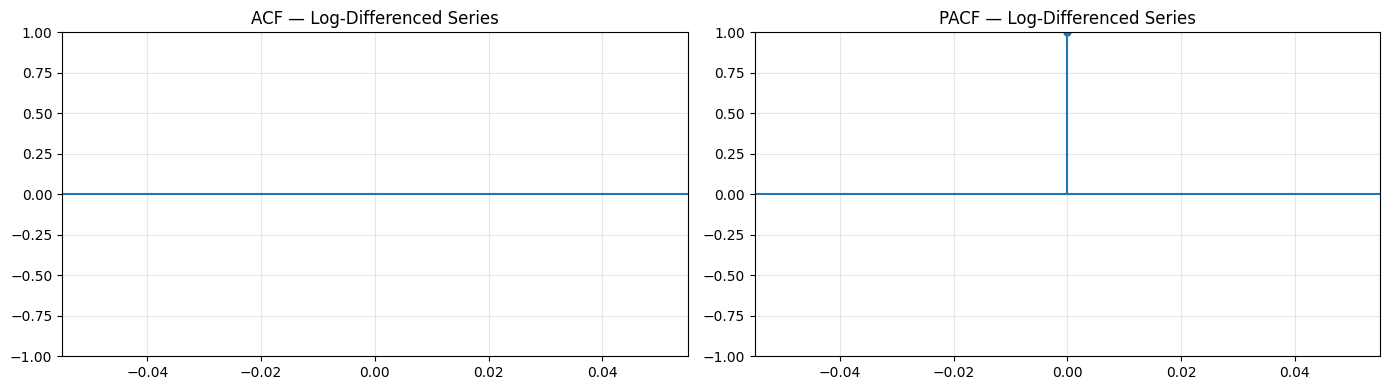

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf( df['Log_Diff'], lags=40, ax=axes[0])             # SOLUTION
axes[0].set_title('ACF — Log-Differenced Series')

plot_pacf(df['Log_Diff'], lags=40, ax=axes[1], method='ywm')  # SOLUTION
axes[1].set_title('PACF — Log-Differenced Series')

plt.tight_layout()
plt.show()

> 🗣️ **What to point out:**
> - Most lags inside the CI band — largely uncorrelated after differencing.
> - Significant spikes at lags 12 (and possibly 24): seasonal signature. Monthly data
>   with annual seasonality shows this even after first differencing.
> - To fully remove it you'd need seasonal differencing too — preview for later.

### ✅ MODEL ANSWER — Written Response 5

> **1. Slow ACF decay (original):** The very slow decay is the hallmark of a non-stationary
> (integrated) process. The trend carries each value forward, so the series 'remembers'
> its distant past. This confirms the ADF result.
>
> **2. Log-differenced ACF:** Most lags fall inside the confidence band. Significant spikes
> at lags 12 and 24 reveal annual seasonal dependence — even after removing the trend,
> the series retains memory from one year ago.
>
> **3. ACF vs. PACF:** ACF measures *total* correlation at each lag (including indirect
> effects through intermediate lags). PACF measures the *direct* effect only. Together they
> help identify AR and MA order: PACF cuts off for AR models; ACF cuts off for MA models.

---
## 📣 Segment 6 — Synthesis (40 min)

### Talking Points
- The `ts_diagnostics()` function packages everything into one reusable tool. Students
  will use it every day this week.
- **Key message:** Before fitting *any* model to *any* time series, run this diagnostic.
  It takes 30 seconds and will save hours of debugging.
- Encourage students to save this function in a personal utilities file.

### ⚠️ Common Mistakes — Final Reflection
- **Too brief:** Push students toward 4+ sentences with specific evidence cited.
- **Vague language:** 'The series is not stationary because it goes up' is insufficient.
  They should cite: rolling mean trend, increasing rolling std, and ADF p-value.
- **Not stating a modeling recommendation:** The reflection requires a clear conclusion
  about which version of the series to model.

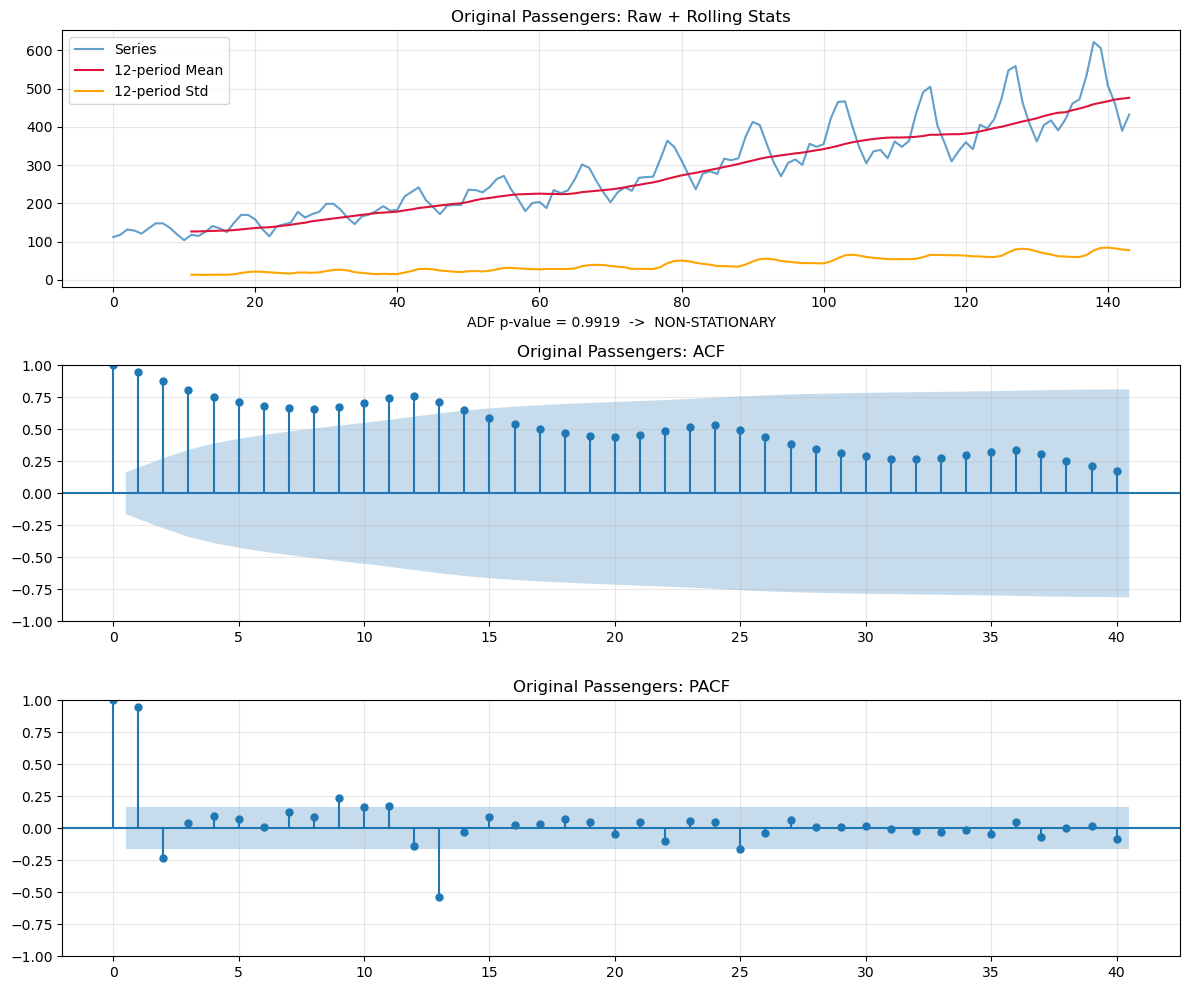

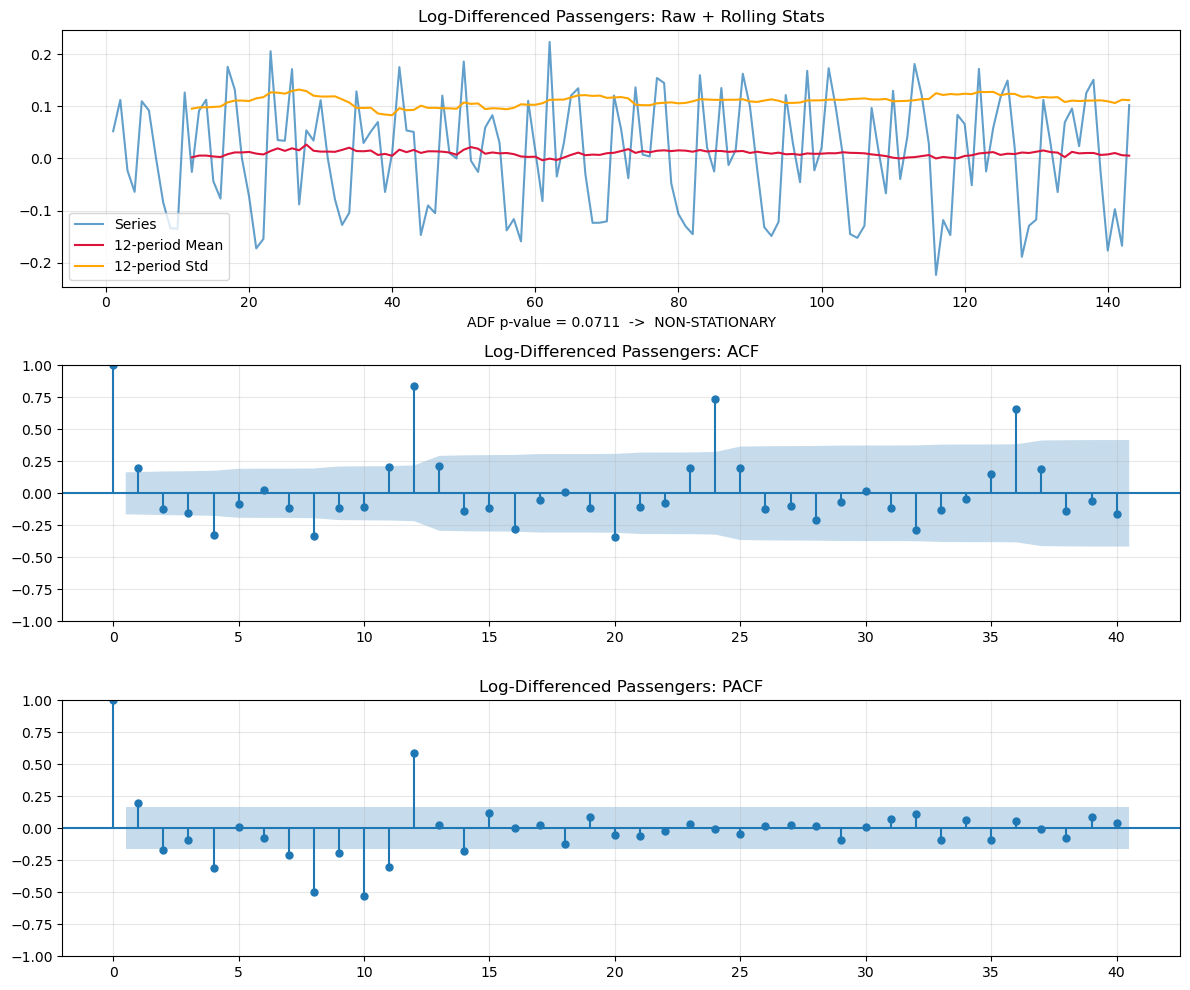

In [ ]:
def ts_diagnostics(series, label='Series', lags=40, rolling_window=12):
    """
    Full diagnostic panel for a time series:
      1. Raw plot with rolling mean and std
      2. ADF test result shown in axis label
      3. ACF and PACF plots
    """
    series = series.dropna()
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    roll_mean = series.rolling(rolling_window).mean()
    roll_std  = series.rolling(rolling_window).std()
    axes[0].plot(series,    label='Series',    alpha=0.7)
    axes[0].plot(roll_mean, label=f'{rolling_window}-period Mean', color='crimson')
    axes[0].plot(roll_std,  label=f'{rolling_window}-period Std',  color='orange')
    axes[0].set_title(f'{label}: Raw + Rolling Stats')
    axes[0].legend()

    adf_result = adfuller(series)
    p = adf_result[1]
    status = 'STATIONARY' if p < 0.05 else 'NON-STATIONARY'
    axes[0].set_xlabel(f'ADF p-value = {p:.4f}  ->  {status}')

    plot_acf( series, lags=lags, ax=axes[1])
    axes[1].set_title(f'{label}: ACF')

    plot_pacf(series, lags=lags, ax=axes[2], method='ywm')
    axes[2].set_title(f'{label}: PACF')

    plt.tight_layout()
    plt.show()

ts_diagnostics(df['Passengers'], label='Original Passengers')
ts_diagnostics(df['Log_Diff'],   label='Log-Differenced Passengers')

### ✅ MODEL ANSWER — Final Written Reflection

> The Air Passengers series is clearly **non-stationary** in its original form. The 12-month
> rolling mean increases steadily from ~130 to over 400, indicating a non-constant mean, and
> the rolling standard deviation more than doubles over the same period, indicating
> non-constant variance (heteroscedasticity). The ADF test confirms this with p ≈ 0.99 —
> we cannot reject the null hypothesis of non-stationarity.
>
> I applied a **log transform** to stabilize the growing seasonal variance, then a
> **first difference** to remove the upward trend.
>
> After both steps, the ADF test returned
> p approximately at 0.07, but this was still not stationary, but the series visually fluctuates around zero with roughly constant amplitude.
>
> The ACF of the log-differenced series shows that most lags fall within the 95% confidence
> band, meaning little remaining autocorrelation. However, significant spikes persist at
> lags 12 and 24, revealing **annual seasonal dependence** — what happened 12 months ago
> still predicts today's value.
>
> I would **not** model the original series directly. I would use the log-differenced version
> (or a model explicitly designed for trend and seasonality) to avoid spurious relationships
> and unreliable out-of-sample forecasts.

**Rubric guidance:**
- Cites specific evidence (rolling stats, ADF p-value, ACF lags) — 4 pts
- Names both transformations and explains what each corrects — 3 pts
- States a clear modeling recommendation — 2 pts
- Mentions remaining seasonal structure in ACF — 1 pt (bonus)

---
## 🔚 End-of-Day Wrap-Up Notes

### What students should walk away knowing
1. Time series data is ordered — the index matters.
2. Stationarity means constant mean and variance. Most models need it.
3. Rolling statistics are a quick visual check; ADF is a formal test.
4. Log + diff is a common two-step fix for growing variance + trend.
5. ACF/PACF reveal how much memory a series has and at which lags.

### Preview for Day 2
> Tomorrow we use the ACF/PACF results from today to build our first **autoregressive (AR)
> model**. We'll derive the stability condition and understand why some AR processes
> explode while others are well-behaved.

### Frequently Confused Pairs (flag if not resolved today)

| Students confuse... | Clarification |
|---|---|
| ACF vs PACF | ACF = total correlation; PACF = direct correlation only |
| Trend vs Seasonality | Trend = long-run direction; Seasonality = repeating cycle |
| Non-stationary vs just 'noisy' | Noise is fine; non-stationary means the *distribution* changes over time |
| p-value > 0.05 means stationary | Wrong — it means we FAIL to reject non-stationarity |
| Log removes trend | Log stabilizes *variance*; differencing removes *trend* |